# Logistic Regression — Strategy A: SMOTE Oversampling

Logistic Regression is trained using Strategy A, where SMOTE is applied to address class imbalance in the training data. SMOTE generates synthetic samples for the minority diabetes class, allowing the model to learn from a more balanced training distribution. Hyperparameter tuning is performed using stratified cross-validation, with SMOTE included inside the pipeline to prevent data leakage between training and validation folds.

In [6]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

In [7]:
X_train_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_train_final.parquet")
X_test_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_test_final.parquet")

y_train = pd.read_parquet("../DATASETS/PREPROCESSED/y_train.parquet")["diabetes"]
y_test = pd.read_parquet("../DATASETS/PREPROCESSED/y_test.parquet")["diabetes"]

In [8]:
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_final, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV ROC AUC:", grid_search.best_score_)

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Best parameters: {'model__C': 0.001, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV ROC AUC: 0.8087897908984167


## Final Test Set Evaluation

After hyperparameter tuning, the best model is evaluated on the held-out test set. The test set is not resampled and therefore preserves the original class distribution. Performance is assessed using accuracy, precision, recall, F1-score, ROC AUC, and the confusion matrix.

In [9]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test_final)
y_pred_proba = best_model.predict_proba(X_test_final)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7119784656796769
ROC AUC: 0.8022120375819021
Confusion Matrix:
[[2987 1232]
 [ 266  716]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.71      0.80      4219
         1.0       0.37      0.73      0.49       982

    accuracy                           0.71      5201
   macro avg       0.64      0.72      0.64      5201
weighted avg       0.81      0.71      0.74      5201



## Exporting Model Results

The final evaluation metrics are exported to a CSV file so they can be combined later in a separate model comparison notebook. This avoids retraining models when creating summary tables and visualizations.

In [10]:
metrics = {

    "Strategy": "SMOTE",

    "Model": "Logistic Regression",

    "Accuracy": accuracy_score(y_test, y_pred),

    "Precision": precision_score(y_test, y_pred),

    "Recall": recall_score(y_test, y_pred),

    "F1-score": f1_score(y_test, y_pred),

    "ROC AUC": roc_auc_score(y_test, y_pred_proba)

}

metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv("../RESULTS/PERFORMANCE/logistic_regression_oversampling_metrics.csv", index=False)

c:\Users\itchy\anaconda3\Lib\site-packages\shap\explainers\_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


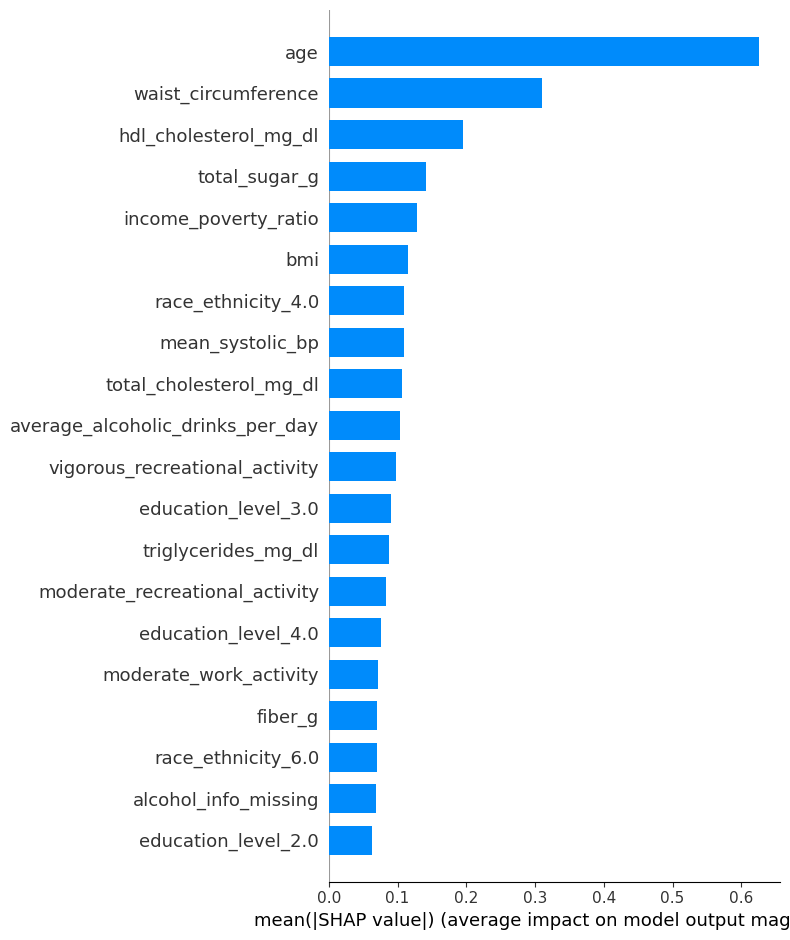

In [ ]:
import numpy as np
import shap

lr_model = best_model.named_steps["model"]

explainer = shap.LinearExplainer(
    lr_model,
    X_train_final,
    feature_perturbation="interventional"
)

shap_values = explainer.shap_values(X_test_final)

shap_importance = np.mean(np.abs(shap_values), axis=0)

shap_results = pd.DataFrame({
    "model": "Logistic Regression",
    "strategy": "SMOTE",
    "method": "SHAP",
    "feature": X_test_final.columns,
    "importance": shap_importance
})

shap_results = shap_results.sort_values("importance", ascending=False).reset_index(drop=True)
shap_results["rank"] = (shap_results["importance"]
                         .rank(method="first", ascending=False)
                         .astype(int))

shap_results = shap_results[["model", "strategy", "method", "feature", "importance", "rank"]]
shap_results.to_csv("../RESULTS/PERFORMANCE/logistic_regression_smote_shap.csv", index=False)

shap.summary_plot(shap_values, X_test_final, plot_type="bar")


In [ ]:
from sklearn.inspection import permutation_importance

lr_model = best_model.named_steps["model"]

perm_result = permutation_importance(
    lr_model,
    X_test_final,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

perm_importance = np.abs(perm_result.importances_mean)
perm_importance = perm_importance / perm_importance.max() if perm_importance.max() != 0 else perm_importance


perm_results = pd.DataFrame({
    "model": "Logistic Regression",
    "strategy": "SMOTE",
    "method": "Permutation",
    "feature": X_test_final.columns,
    "importance": perm_importance
})

perm_results = perm_results.sort_values("importance", ascending=False).reset_index(drop=True)
perm_results["rank"] = (
    perm_results["importance"]
    .rank(method="first", ascending=False)
    .astype(int)
)

perm_results = perm_results[["model", "strategy", "method", "feature", "importance", "rank"]]
perm_results.to_csv("../RESULTS/PERFORMANCE/logistic_regression_permutation_metrics_smote.csv", index=False)

In [ ]:
# Model-specific feature importance using absolute coefficient values
lr_model = best_model.named_steps["model"]

coef_importance = np.abs(lr_model.coef_.ravel())

coef_results = pd.DataFrame({
    "model": "Logistic Regression",
    "strategy": "SMOTE",
    "method": "Coefficient",
    "feature": X_test_final.columns,
    "importance": coef_importance
})

coef_results = coef_results.sort_values("importance", ascending=False).reset_index(drop=True)
coef_results["rank"] = (
    coef_results["importance"]
    .rank(method="first", ascending=False)
    .astype(int)
)

coef_results = coef_results[["model", "strategy", "method", "feature", "importance", "rank"]]
coef_results.to_csv("../RESULTS/PERFORMANCE/logistic_regression_smote_coefficient.csv", index=False)